# Naive Bayes Classifier

This notebook trains a Gaussian Naive Bayes classifier on the Dry Bean dataset, evaluates its performance, and visualizes the confusion matrix.

In [5]:
import io
from pathlib import Path
import zipfile
from io import BytesIO

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from scipy.io import arff

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')


In [6]:
DATASET_CANDIDATES = [
    Path('dry_bean.csv'),
    Path('dry_bean_dataset.csv'),
    Path('Dry_Bean_Dataset.csv'),
]
DATASET_URL = 'https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip'

def load_dataset():
    for path in DATASET_CANDIDATES:
        if path.exists():
            return pd.read_csv(path)

    response = requests.get(DATASET_URL, timeout=60)
    response.raise_for_status()

    if response.headers.get('Content-Type', '').startswith('application/zip') or response.url.endswith('.zip'):
        with zipfile.ZipFile(BytesIO(response.content)) as archive:
            arff_name = next(name for name in archive.namelist() if name.endswith('.arff'))
            with archive.open(arff_name) as arff_file_binary:
                # Read the binary content and decode it to a string
                arff_content = arff_file_binary.read().decode('utf-8')
                # Wrap the string content in StringIO for arff.loadarff
                raw_data, _ = arff.loadarff(io.StringIO(arff_content))
            df = pd.DataFrame(raw_data)
            for col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].apply(lambda value: value.decode() if isinstance(value, (bytes, bytearray)) else value)
            return df

    # Fallback for non-zip (e.g., direct CSV link, though not typical for this URL)
    return pd.read_csv(io.StringIO(response.text))

df = load_dataset()
print(df.head())
print('\nClass distribution:')
print(df['Class'].value_counts())

      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395.0    610.291       208.178117       173.888747      1.197191   
1  28734.0    638.018       200.524796       182.734419      1.097356   
2  29380.0    624.110       212.826130       175.931143      1.209713   
3  30008.0    645.884       210.557999       182.516516      1.153638   
4  30140.0    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812     28715.0     190.141097  0.763923  0.988856   0.958027   
1      0.411785     29172.0     191.272750  0.783968  0.984986   0.887034   
2      0.562727     29690.0     193.410904  0.778113  0.989559   0.947849   
3      0.498616     30724.0     195.467062  0.782681  0.976696   0.903936   
4      0.333680     30417.0     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358    

In [7]:
X = df.drop(columns=['Class']).astype(float)
y = df['Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

In [8]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

metrics = {
    'Accuracy': accuracy,
    'AUC': auc,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'MCC': mcc,
}
print('\nEvaluation metrics:')
print(pd.DataFrame(metrics, index=['Score']).T.round(4))

Classification report:
              precision    recall  f1-score   support

    BARBUNYA       0.68      0.46      0.55       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.68      0.83      0.75       326
    DERMASON       0.87      0.83      0.85       709
       HOROZ       0.78      0.79      0.79       386
       SEKER       0.68      0.71      0.70       406
        SIRA       0.73      0.76      0.75       527

    accuracy                           0.76      2723
   macro avg       0.77      0.77      0.77      2723
weighted avg       0.77      0.76      0.76      2723


Evaluation metrics:
            Score
Accuracy   0.7639
AUC        0.9672
Precision  0.7654
Recall     0.7639
F1 Score   0.7615
MCC        0.7154


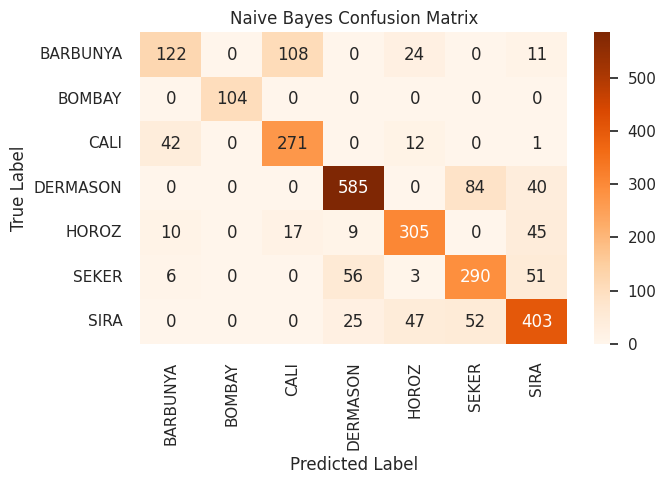

In [9]:
cm = confusion_matrix(y_test, y_pred)
class_names = label_encoder.classes_

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Naive Bayes Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [10]:
output_dir = Path('model')
output_dir.mkdir(exist_ok=True, parents=True)
joblib.dump(model, output_dir / 'naive_bayes.joblib')
print(f'Saved model to {output_dir / "naive_bayes.joblib"}')

Saved model to model/naive_bayes.joblib
